# Part-mask gallery -- what BPAM actually segments each person into

Loads the real Stage 0 checkpoint (auto-detects ViT-B/16 if it exists yet, otherwise falls back
to the real, complete RN50 checkpoint), runs it on a handful of random Market1501 people, and
turns each person's predicted per-pixel part-attention map into one flat, colorized segmentation
mask (argmax over the M=1+K branches at every pixel -- not K separate heatmaps). Each person's
(image | mask) pair is tightly packed with zero margin, saved as its own PNG, and also combined
into one grid PNG for dropping straight into a slide.

In [1]:
import os
import os.path as osp
import random

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms as tv_transforms

from pcr import datasets
from pcr.models.clip_dense_part_encoder import CLIP_MEAN, CLIP_STD
from pcr.models.clip_rn50_bpam_encoder import ClipRN50BPAMEncoder
from pcr.models.clip_vit_bpam_encoder import ClipViTBPAMEncoder

HEIGHT, WIDTH = 384, 128
NUM_PARTS = 5
NUM_SAMPLES = 6
GRID_COLS = 2          # people per row in the combined contact sheet -- must divide NUM_SAMPLES
SEED = 7
OUT_DIR = 'examples/logs/part_mask_gallery'
os.makedirs(OUT_DIR, exist_ok=True)

# Prefer a real ViT-B/16 Stage 0 checkpoint if one has finished training by the time this runs;
# otherwise fall back to the real, complete RN50 checkpoint (20 real epochs, 75.3% pixel-acc --
# not a smoke-test artifact). Both share the exact same ClipBPAMEncoder interface, so nothing
# else in this notebook needs to change based on which one loads.
VIT_CKPT = 'examples/logs/stage0_bpa_vit_b16/model_best.pth.tar'
RN50_CKPT = 'examples/logs/stage0_bpa_rn50/model_best.pth.tar'

if osp.isfile(VIT_CKPT):
    encoder = ClipViTBPAMEncoder(clip_arch='ViT-B/16', height=HEIGHT, width=WIDTH,
                                  num_parts=NUM_PARTS, checkpoint_path=VIT_CKPT, device='cuda').cuda()
    ARCH_NAME, CKPT_USED = 'ViT-B/16', VIT_CKPT
elif osp.isfile(RN50_CKPT):
    encoder = ClipRN50BPAMEncoder(clip_arch='RN50', height=HEIGHT, width=WIDTH,
                                   num_parts=NUM_PARTS, checkpoint_path=RN50_CKPT, device='cuda').cuda()
    ARCH_NAME, CKPT_USED = 'RN50', RN50_CKPT
else:
    raise FileNotFoundError(
        "No Stage 0 checkpoint at either {} or {} -- run Stage 0 first.".format(VIT_CKPT, RN50_CKPT))

encoder.eval()
for p in encoder.parameters():
    p.requires_grad_(False)
print('Using {} checkpoint: {}'.format(ARCH_NAME, CKPT_USED))

Using RN50 checkpoint: examples/logs/stage0_bpa_rn50/model_best.pth.tar


In [2]:
dataset = datasets.create('market1501', osp.join('../datasets', 'market1501'))

random.seed(SEED)
samples = random.sample(dataset.train, NUM_SAMPLES)

# CLIP's own normalization, not ImageNet stats -- both checkpoints above are CLIP-backbone-based.
normalizer = tv_transforms.Normalize(mean=list(CLIP_MEAN), std=list(CLIP_STD))
to_model = tv_transforms.Compose([
    tv_transforms.Resize((HEIGHT, WIDTH), interpolation=tv_transforms.InterpolationMode.BICUBIC),
    tv_transforms.ToTensor(),
    normalizer,
])

raw_images, model_inputs, pids = [], [], []
for fname, pid, camid in samples:
    fpath = fname if dataset.images_dir is None else osp.join(dataset.images_dir, fname)
    img = Image.open(fpath).convert('RGB')
    raw_images.append(np.array(img.resize((WIDTH, HEIGHT))))
    model_inputs.append(to_model(img))
    pids.append(pid)

batch = torch.stack(model_inputs, dim=0).cuda()

with torch.no_grad():
    f_out, vis, pixels_cls_scores = encoder.forward_full(batch)
    probs = F.softmax(pixels_cls_scores, dim=1)
    probs_up = F.interpolate(probs, size=(HEIGHT, WIDTH), mode='bilinear', align_corners=True)
    class_map = probs_up.argmax(dim=1)  # [B, H, W], values 0..NUM_PARTS

class_map = class_map.cpu().numpy()
print('class_map shape:', class_map.shape, ' pids:', pids)

=> Market1501 loaded
Dataset statistics:
  ----------------------------------------
  subset   | # ids | # images | # cameras
  ----------------------------------------
  train    |   751 |    12936 |         6
  query    |   750 |     3368 |         6
  gallery  |   751 |    15913 |         6
  ----------------------------------------


class_map shape: (6, 384, 128)  pids: [427, 476, 56, 327, 351, 342]


## Each person, separately -- tightly packed, zero margin

`(original image | colorized mask)`, touching pixel-to-pixel with nothing in between. Each one is
saved as its own PNG in `examples/logs/part_mask_gallery/`.

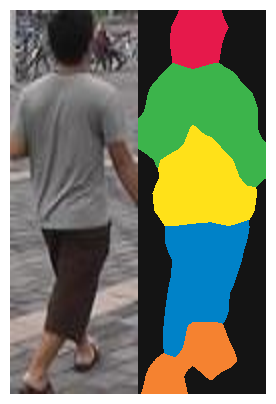

saved: examples/logs/part_mask_gallery/person_00_pid427.png


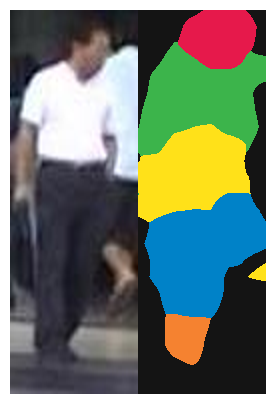

saved: examples/logs/part_mask_gallery/person_01_pid476.png


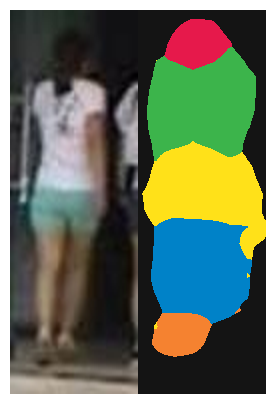

saved: examples/logs/part_mask_gallery/person_02_pid56.png


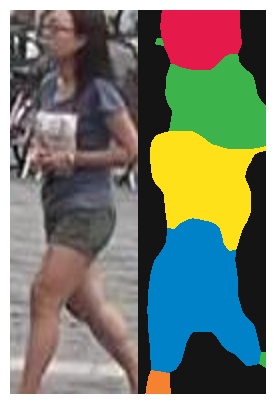

saved: examples/logs/part_mask_gallery/person_03_pid327.png


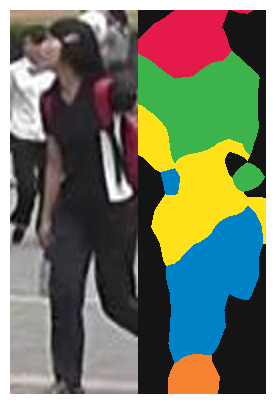

saved: examples/logs/part_mask_gallery/person_04_pid351.png


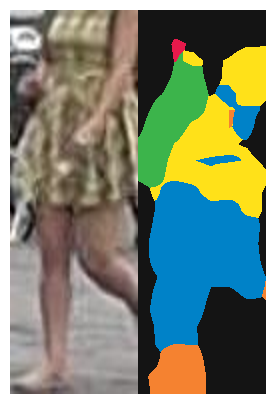

saved: examples/logs/part_mask_gallery/person_05_pid342.png


In [3]:
PALETTE = np.array([
    [20,  20,  20],   # background
    [230, 25,  75],   # part_1
    [60,  180, 75],   # part_2
    [255, 225, 25],   # part_3
    [0,   130, 200],  # part_4
    [245, 130, 48],   # part_5
], dtype=np.uint8)
PART_NAMES = ['background', 'part_1', 'part_2', 'part_3', 'part_4', 'part_5']

def colorize(cmap):
    return PALETTE[cmap]

def show_tight(img):
    """imshow with zero figure margin -- the figure's own pixel size matches the array exactly,
    so there's no matplotlib axis padding around it, only the array's own content."""
    fig = plt.figure(figsize=(img.shape[1] / 100, img.shape[0] / 100), dpi=100)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.imshow(img)
    ax.axis('off')
    plt.show()

composites = []
for i in range(NUM_SAMPLES):
    mask_rgb = colorize(class_map[i])
    composite = np.hstack([raw_images[i], mask_rgb])  # image | mask, touching, zero gap
    composites.append(composite)

    out_path = osp.join(OUT_DIR, 'person_{:02d}_pid{}.png'.format(i, pids[i]))
    Image.fromarray(composite).save(out_path)
    show_tight(composite)
    print('saved:', out_path)

## All people, one grid -- for pasting straight into a slide

Same zero-margin technique, `GRID_COLS` people per row, saved as one PNG.

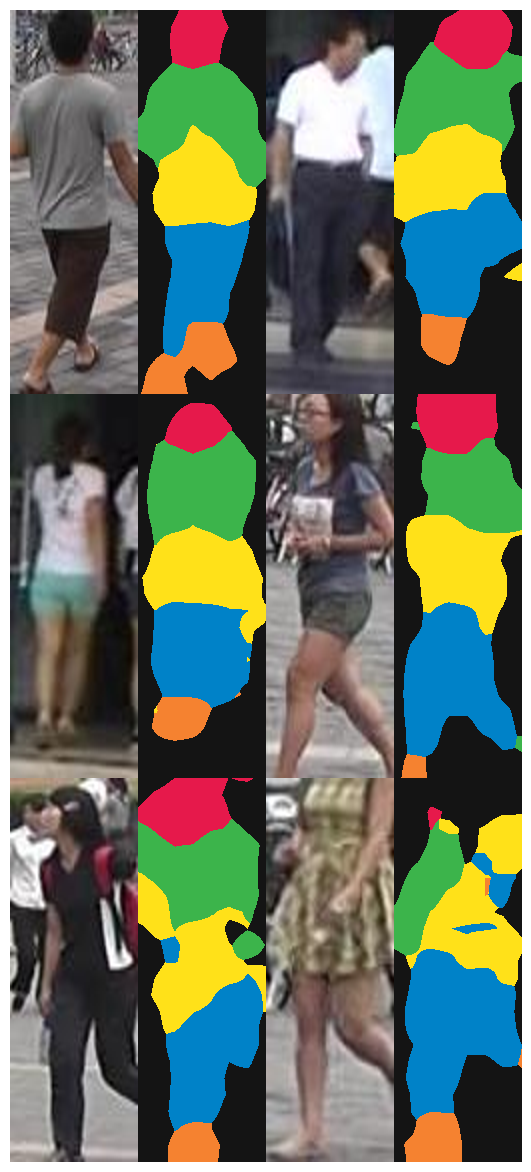

saved combined grid: examples/logs/part_mask_gallery/all_people_grid.png  shape: (1152, 512, 3)


In [4]:
assert NUM_SAMPLES % GRID_COLS == 0, "pick NUM_SAMPLES divisible by GRID_COLS (or set GRID_COLS=1)"
rows = [np.hstack(composites[i:i + GRID_COLS]) for i in range(0, NUM_SAMPLES, GRID_COLS)]
grid = np.vstack(rows)

grid_path = osp.join(OUT_DIR, 'all_people_grid.png')
Image.fromarray(grid).save(grid_path)
show_tight(grid)
print('saved combined grid:', grid_path, ' shape:', grid.shape)

## Color legend

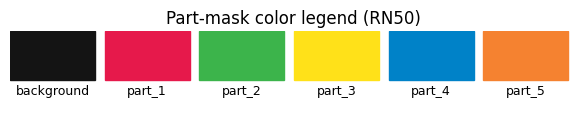

saved legend: examples/logs/part_mask_gallery/legend.png


In [5]:
fig, ax = plt.subplots(figsize=(6, 1.3))
for i, (color, name) in enumerate(zip(PALETTE, PART_NAMES)):
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 1, color=color / 255))
    ax.text(i + 0.45, -0.3, name, ha='center', fontsize=9)
ax.set_xlim(0, len(PALETTE))
ax.set_ylim(-0.6, 1)
ax.axis('off')
plt.title('Part-mask color legend ({})'.format(ARCH_NAME))
plt.tight_layout()
legend_path = osp.join(OUT_DIR, 'legend.png')
plt.savefig(legend_path, dpi=150, bbox_inches='tight')
plt.show()
print('saved legend:', legend_path)